In [1]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta

import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

utc_now_iso = datetime.now(timezone.utc).isoformat()
print(utc_now_iso)

2025-08-16T15:25:47.172784+00:00


In [3]:
base_url = "http://personal-laptop.local:8080/"


In [4]:
def create_url(base_url,first_part_endpoint,second_part_endpoint):
    return base_url + first_part_endpoint + second_part_endpoint
def getData(url):
    response = requests.get(url)

    # Check response status
    if response.status_code == 200:
        
        data = response.json()
        print(f"Received {len(data)} records.")
        return data
    else:
        print(f"Error: {response.status_code}")


def saveDataIntoDataFolder(data,data_file_name):
    script_dir = Path().resolve().parent
    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (data_file_name + ".json")
    with open(file_path, 'w') as file:
        if isinstance(data, pd.DataFrame):
            print("It's a DataFrame")
            if  data.empty():
                print("No data to save.")
            else:
                data.to_json(file_path, orient='records', lines=False)             
                print(f"Data saved to {file_path}")

        else:  
            print("It's NOT a DataFrame.")    
            if not data:
                print("No data to save.")
            else:    
                json.dump(data, file)
                print(f"Data saved to {file_path}")

        
def getDataFromServerThenSaveThemIntoDataFolder(url,data_file_name):
    data = getData(url)
    saveDataIntoDataFolder(data,data_file_name)
    

def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent

    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None

def countPositionOfPollutantSource(df_userInputData_smallScale):
    df_unique_position_count = df_userInputData_smallScale.groupby(['front-wall', 'side-right-wall','back-wall','side-left-wall'], dropna=False).size().reset_index(name='count')
    return df_unique_position_count

    
        

In [5]:
def getTimeSeries(df_userInputData_smallScale):
    first_row= df_userInputData_smallScale.iloc[0]
    last_row = df_userInputData_smallScale.iloc[-1]
    start_time = first_row["epoch_ms"]
    end_time   = last_row["epoch_ms"] 
    first_part_endpoint = "timeSeriesEndpoints/"
    second_part_endpoint = "getTimeSeriesData?start=" + str(start_time) + '&end=' +str(end_time)
    file_name="TimeSeries"
    url = create_url(base_url,first_part_endpoint,second_part_endpoint)
    getDataFromServerThenSaveThemIntoDataFolder(url,file_name)
    df_timeSeries = loadDataFromFile(file_name)
    return df_timeSeries
def tranformTimeSeries(df_timeSeries):
    # 1. Select only the needed column
    df_timeSeriesExperiments = df_timeSeries[['timestamp', 'Id', 'BME680:breathVocEquivalent']].copy()
    # 2. Convert `timestamp` (UTC) to Europe/Athens tz-aware datetime
    df_timeSeriesExperiments['timestamp'] = (
        pd.to_datetime(df_timeSeriesExperiments['timestamp'], utc=True)
          .dt.tz_convert('Europe/Athens')
    )
    # 3. Create the two “Id=…:” columns
    
    df_timeSeriesExperiments['Id=1:BME680:breathVocEquivalent'] = np.where(
        df_timeSeriesExperiments['Id'] == 1, df_timeSeriesExperiments['BME680:breathVocEquivalent'], np.nan
    )
    df_timeSeriesExperiments['Id=2:BME680:breathVocEquivalent'] = np.where(
        df_timeSeriesExperiments['Id'] == 2, df_timeSeriesExperiments['BME680:breathVocEquivalent'], np.nan
    )
    
    # 4. Set timestamp as the row index
    #df_timeSeriesExperiments.set_index('timestamp', inplace=True)
    
    # 5. Drop the old Id+raw measurement columns
    df_timeSeriesExperiments = df_timeSeriesExperiments.drop(
        columns=['Id', 'BME680:breathVocEquivalent']
    )
    return df_timeSeriesExperiments

In [6]:
def sortUserIputDataToListBasedOfPosition(df_userInputData_smallScale):
    
    list_of_userInputData_smallScale_based_on_position = []
    
    for idx, row in df_unique_position_count.iterrows():
        mask = (
            (df_userInputData_smallScale['experimentState'] == "InsertingSourcePollutant") &
            (
                (df_userInputData_smallScale['front-wall'] == row['front-wall']) |
                (np.isnan(df_userInputData_smallScale['front-wall']) & np.isnan(row['front-wall']))
            ) &
            (
                (df_userInputData_smallScale['side-left-wall'] == row['side-left-wall']) |
                (np.isnan(df_userInputData_smallScale['side-left-wall']) & np.isnan(row['side-left-wall']))
            ) &
            (
                (df_userInputData_smallScale['back-wall'] == row['back-wall']) |
                (np.isnan(df_userInputData_smallScale['back-wall']) & np.isnan(row['back-wall']))
            ) &
            (
                (df_userInputData_smallScale['side-right-wall'] == row['side-right-wall']) |
                (np.isnan(df_userInputData_smallScale['side-right-wall']) & np.isnan(row['side-right-wall']))
            )
        )

        df_userInputData_individual_position = df_userInputData_smallScale[mask]
        list_of_userInputData_smallScale_based_on_position.append(df_userInputData_individual_position)

    return list_of_userInputData_smallScale_based_on_position


In [7]:
def print_time_series_based_of_position(index,df_userInputData_smallScale,df_timeSeriesExperiments,
                                        list_of_userInputData_smallScale_based_of_position,oldData = False):
    
    df_userInputData_smallScale_based_of_position = list_of_userInputData_smallScale_based_of_position[index]
    num_experiments = df_userInputData_smallScale_based_of_position.shape[0]
    fig, axes = plt.subplots(num_experiments, figsize=(14, 3 * num_experiments), sharex=False)
    if num_experiments == 1:
        axes = [axes]  # Wrap single Axes into a list
    title = f"BME680:breathVocEquivalent at the pollution source position to be "
    if (pd.isna(df_userInputData_smallScale_based_of_position.iloc[0]['front-wall'])==False):
       title =title + f"{df_userInputData_smallScale_based_of_position.iloc[0]['front-wall']} meters from the front wall, "
    if (pd.isna(df_userInputData_smallScale_based_of_position.iloc[0]['back-wall'])==False):
       title =title +f"{df_userInputData_smallScale_based_of_position.iloc[0]['back-wall']} meters from the back wall, "
    if (pd.isna(df_userInputData_smallScale_based_of_position.iloc[0]['side-right-wall'])==False):
       title =title+ f"{df_userInputData_smallScale_based_of_position.iloc[0]['side-right-wall']} meters from the side right wall, "
    if (pd.isna(df_userInputData_smallScale_based_of_position.iloc[0]['side-left-wall'])==False):
       title =title+ f"{df_userInputData_smallScale_based_of_position.iloc[0]['side-left-wall']} meters from the side left wall, "

    title =title +"at the room:"+df_userInputData_smallScale_based_of_position.iloc[0]["room"]   
    fig.suptitle(title)

    for i, (idx, row) in enumerate(df_userInputData_smallScale_based_of_position.iterrows()):
        # Filter the time series between start and end 
                  
        if (oldData == False):
            if 'timestamp:Starting Experiment' in df_userInputData_smallScale_based_of_position.columns :
                starting_experiment_timestamp =  df_userInputData_smallScale_based_of_position.iloc[i]["timestamp:Starting Experiment"]    
            else:    
                starting_experiment_timestamp =  df_userInputData_smallScale.iloc[idx - 1]["timestamp_local"]    
                
            if 'timestamp:Ending Experiment' in df_userInputData_smallScale_based_of_position.columns :
            
                removing_source_timestamp = df_userInputData_smallScale_based_of_position.iloc[i]["timestamp:Ending Experiment"] 
                
            else:   
                
                removing_source_timestamp = df_userInputData_smallScale.iloc[idx + 1]["timestamp_local"] 

        #create a pseudo start experiment 3 minutes before the source insertion    
        elif  (oldData == True): 
            starting_experiment_timestamp = df_userInputData_smallScale.iloc[idx]["timestamp_local"] - datetime.timedelta(minutes=2)
            removing_source_timestamp = df_userInputData_smallScale.iloc[idx] + datetime.timedelta(minutes=3)

        
        inserting_source_timestamp_condition  = (df_timeSeriesExperiments["timestamp"] >= starting_experiment_timestamp )    
        removing_source_timestamp_condition =   (df_timeSeriesExperiments["timestamp"] <= removing_source_timestamp  )

        data = df_timeSeriesExperiments[removing_source_timestamp_condition & inserting_source_timestamp_condition]   
        # Plot VOC data
        sns.lineplot(
            data=data, 
            x="timestamp",
            y='Id=1:BME680:breathVocEquivalent',
            label="Id=1",
            marker='o',
            ax=axes[i]
        )
        sns.lineplot(
            data=data,
            x="timestamp",
            y='Id=2:BME680:breathVocEquivalent',
            label="Id=2",
            marker='s',
            ax=axes[i]
        )
        print()
        subtitle="Στοιχεία για το μενωμένο πείραμα:"
        subtitle= subtitle+"Αντικείμενο που χρησιμοποιείται¨"+row["item-used"]+", "
        if (pd.isna(row["are-doors-opened"]) == False):
            subtitle = subtitle + "Οι πόρτες είναι ανοιχτές, "
        if (pd.isna(row["are-fans-on"]) == False):
            subtitle = subtitle + "Οι ανεμιστήρες είναι ενεργοποιημένοι, "
        if (pd.isna(row["are-people-inside"]) == False):
            subtitle = subtitle + "Βρίσκονται άνθρωποι μέσα, "
        if (pd.isna(row["are-windows-opened"]) == False):
            subtitle = subtitle + "Τα παράθυρα είναι ανοιχτά, "
        if (pd.isna(row["notes"])== False):
            subtitle= subtitle + "Σημειώσεις:"+ row["notes"]
        axes[i].set_title(subtitle);

        # Draw vertical line at inserting source timestamp
        inserting_source = df_userInputData_smallScale.iloc[idx]["timestamp_local"]
        if inserting_source:
            axes[i].axvline(
                inserting_source, 
                color='red', 
                linestyle='--', 
                linewidth=2,
                label='inserting_source'
            )
        
        axes[i].set_xlabel("Timestamp")
        axes[i].set_ylabel("VOC")
        axes[i].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    print("\n")

In [ ]:
def create_url(base_url,first_part_endpoint,second_part_endpoint):
    return base_url + first_part_endpoint + second_part_endpoint
getDataFromServerThenSaveThemIntoDataFolder(url,data_file_name)

In [8]:
df_userInputData_smallScale = loadDataFromFile("df_userInputData_smallScale")

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 129 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/df_userInputData_smallScale.json


In [9]:
df_userInputData_smallScale

,_id,experimentState,timestamp,userInputCategory,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,pollutant-type,quantity-used,room,side-right-wall,back-wall,side-left-wall,are-fans-on,epoch_ms,timestamp_local
0,{'$oid': '687bb2e32f9e1ee587c33549'},StartingExperiment,{'$date': 1752937187709},ExperimentState,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,1752937187709,2025-07-19 14:59:47.709
1,{'$oid': '687bb3e92f9e1ee587c337ad'},InsertingSourcePollutant,{'$date': 1752937449439},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752937449439,2025-07-19 15:04:09.439
2,{'$oid': '687bb4da2f9e1ee587c339fe'},RemovingSourcePollutant,{'$date': 1752937690518},ExperimentState,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,1752937690518,2025-07-19 15:08:10.518
3,{'$oid': '687bb6452f9e1ee587c33d06'},StartingExperiment,{'$date': 1752938053589},ExperimentState,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,1752938053589,2025-07-19 15:14:13.589
4,{'$oid': '687bb6f62f9e1ee587c33e98'},InsertingSourcePollutant,{'$date': 1752938230079},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752938230079,2025-07-19 15:17:10.079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,{'$oid': '6887fafc2b6a61abefaed5be'},InsertingSourcePollutant,{'$date': 1753742076827},ExperimentState,on,None,NaN,NaN,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,1.7,0.3,NaN,1753742076827,2025-07-28 22:34:36.827
125,{'$oid': '6887fc7b2b6a61abefaed8e1'},RemovingSourcePollutant,{'$date': 1753742459114},ExperimentState,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,1753742459114,2025-07-28 22:40:59.114
126,{'$oid': '6887fe542b6a61abefaedcda'},StartingExperiment,{'$date': 1753742932141},ExperimentState,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,1753742932141,2025-07-28 22:48:52.141
127,{'$oid': '6887fef12b6a61abefaede43'},InsertingSourcePollutant,{'$date': 1753743089729},ExperimentState,on,None,NaN,NaN,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,1.7,0.3,NaN,1753743089729,2025-07-28 22:51:29.729


In [10]:
df_unique_position_count = countPositionOfPollutantSource(df_userInputData_smallScale)
df_unique_position_count

,front-wall,side-right-wall,back-wall,side-left-wall,count
0,1.8,NaN,NaN,1.1,12
1,NaN,0.6,2.0,NaN,10
2,NaN,NaN,1.2,1.2,10
3,NaN,NaN,1.7,0.3,11
4,NaN,NaN,NaN,NaN,86


In [11]:
df_timeSeriesExperiments = loadDataFromFile("df_timeSeriesExperiments")

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 98914 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/df_timeSeriesExperiments.json


In [12]:
df_timeSeriesExperiments

,timestamp,Id=1:BME680:breathVocEquivalent,Id=2:BME680:breathVocEquivalent
0,2025-07-19 14:59:48,NaN,0.685445
1,2025-07-19 14:59:49,2.118851,NaN
2,2025-07-19 14:59:51,NaN,0.681077
3,2025-07-19 14:59:52,2.127717,NaN
4,2025-07-19 14:59:54,NaN,0.689541
...,...,...,...
98909,2025-07-28 23:00:13,NaN,0.652596
98910,2025-07-28 23:00:15,0.891208,NaN
98911,2025-07-28 23:00:16,NaN,0.649371
98912,2025-07-28 23:00:18,0.898170,NaN


In [13]:
list_of_userInputData_smallScale_based_on_position = sortUserIputDataToListBasedOfPosition(df_userInputData_smallScale)
list_of_userInputData_smallScale_based_on_position[0]

,_id,experimentState,timestamp,userInputCategory,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,pollutant-type,quantity-used,room,side-right-wall,back-wall,side-left-wall,are-fans-on,epoch_ms,timestamp_local
1,{'$oid': '687bb3e92f9e1ee587c337ad'},InsertingSourcePollutant,{'$date': 1752937449439},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752937449439,2025-07-19 15:04:09.439
4,{'$oid': '687bb6f62f9e1ee587c33e98'},InsertingSourcePollutant,{'$date': 1752938230079},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752938230079,2025-07-19 15:17:10.079
7,{'$oid': '687bba292f9e1ee587c34606'},InsertingSourcePollutant,{'$date': 1752939049527},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752939049527,2025-07-19 15:30:49.527
10,{'$oid': '687bc4062f9e1ee587c35acd'},InsertingSourcePollutant,{'$date': 1752941574048},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752941574048,2025-07-19 16:12:54.048
13,{'$oid': '687bcbf52f9e1ee587c36c6b'},InsertingSourcePollutant,{'$date': 1752943605578},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752943605578,2025-07-19 16:46:45.578
16,{'$oid': '687bd5102f9e1ee587c3800b'},InsertingSourcePollutant,{'$date': 1752945936836},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752945936836,2025-07-19 17:25:36.836
19,{'$oid': '687cf31b9ca8d3ed9388a101'},InsertingSourcePollutant,{'$date': 1753019163466},ExperimentState,on,None,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1753019163466,2025-07-20 13:46:03.466
22,{'$oid': '687d08169ca8d3ed9388c9c1'},InsertingSourcePollutant,{'$date': 1753024534869},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1753024534869,2025-07-20 15:15:34.869
25,{'$oid': '687d1a9f29a17fa9a903c98f'},InsertingSourcePollutant,{'$date': 1753029279532},ExperimentState,on,None,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1753029279532,2025-07-20 16:34:39.532
28,{'$oid': '687d31b3ef9fa667a2542024'},InsertingSourcePollutant,{'$date': 1753035187541},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1753035187541,2025-07-20 18:13:07.541


Starting experiment is more than two minutes:
False
Ending experiment is more than two minutes:
True













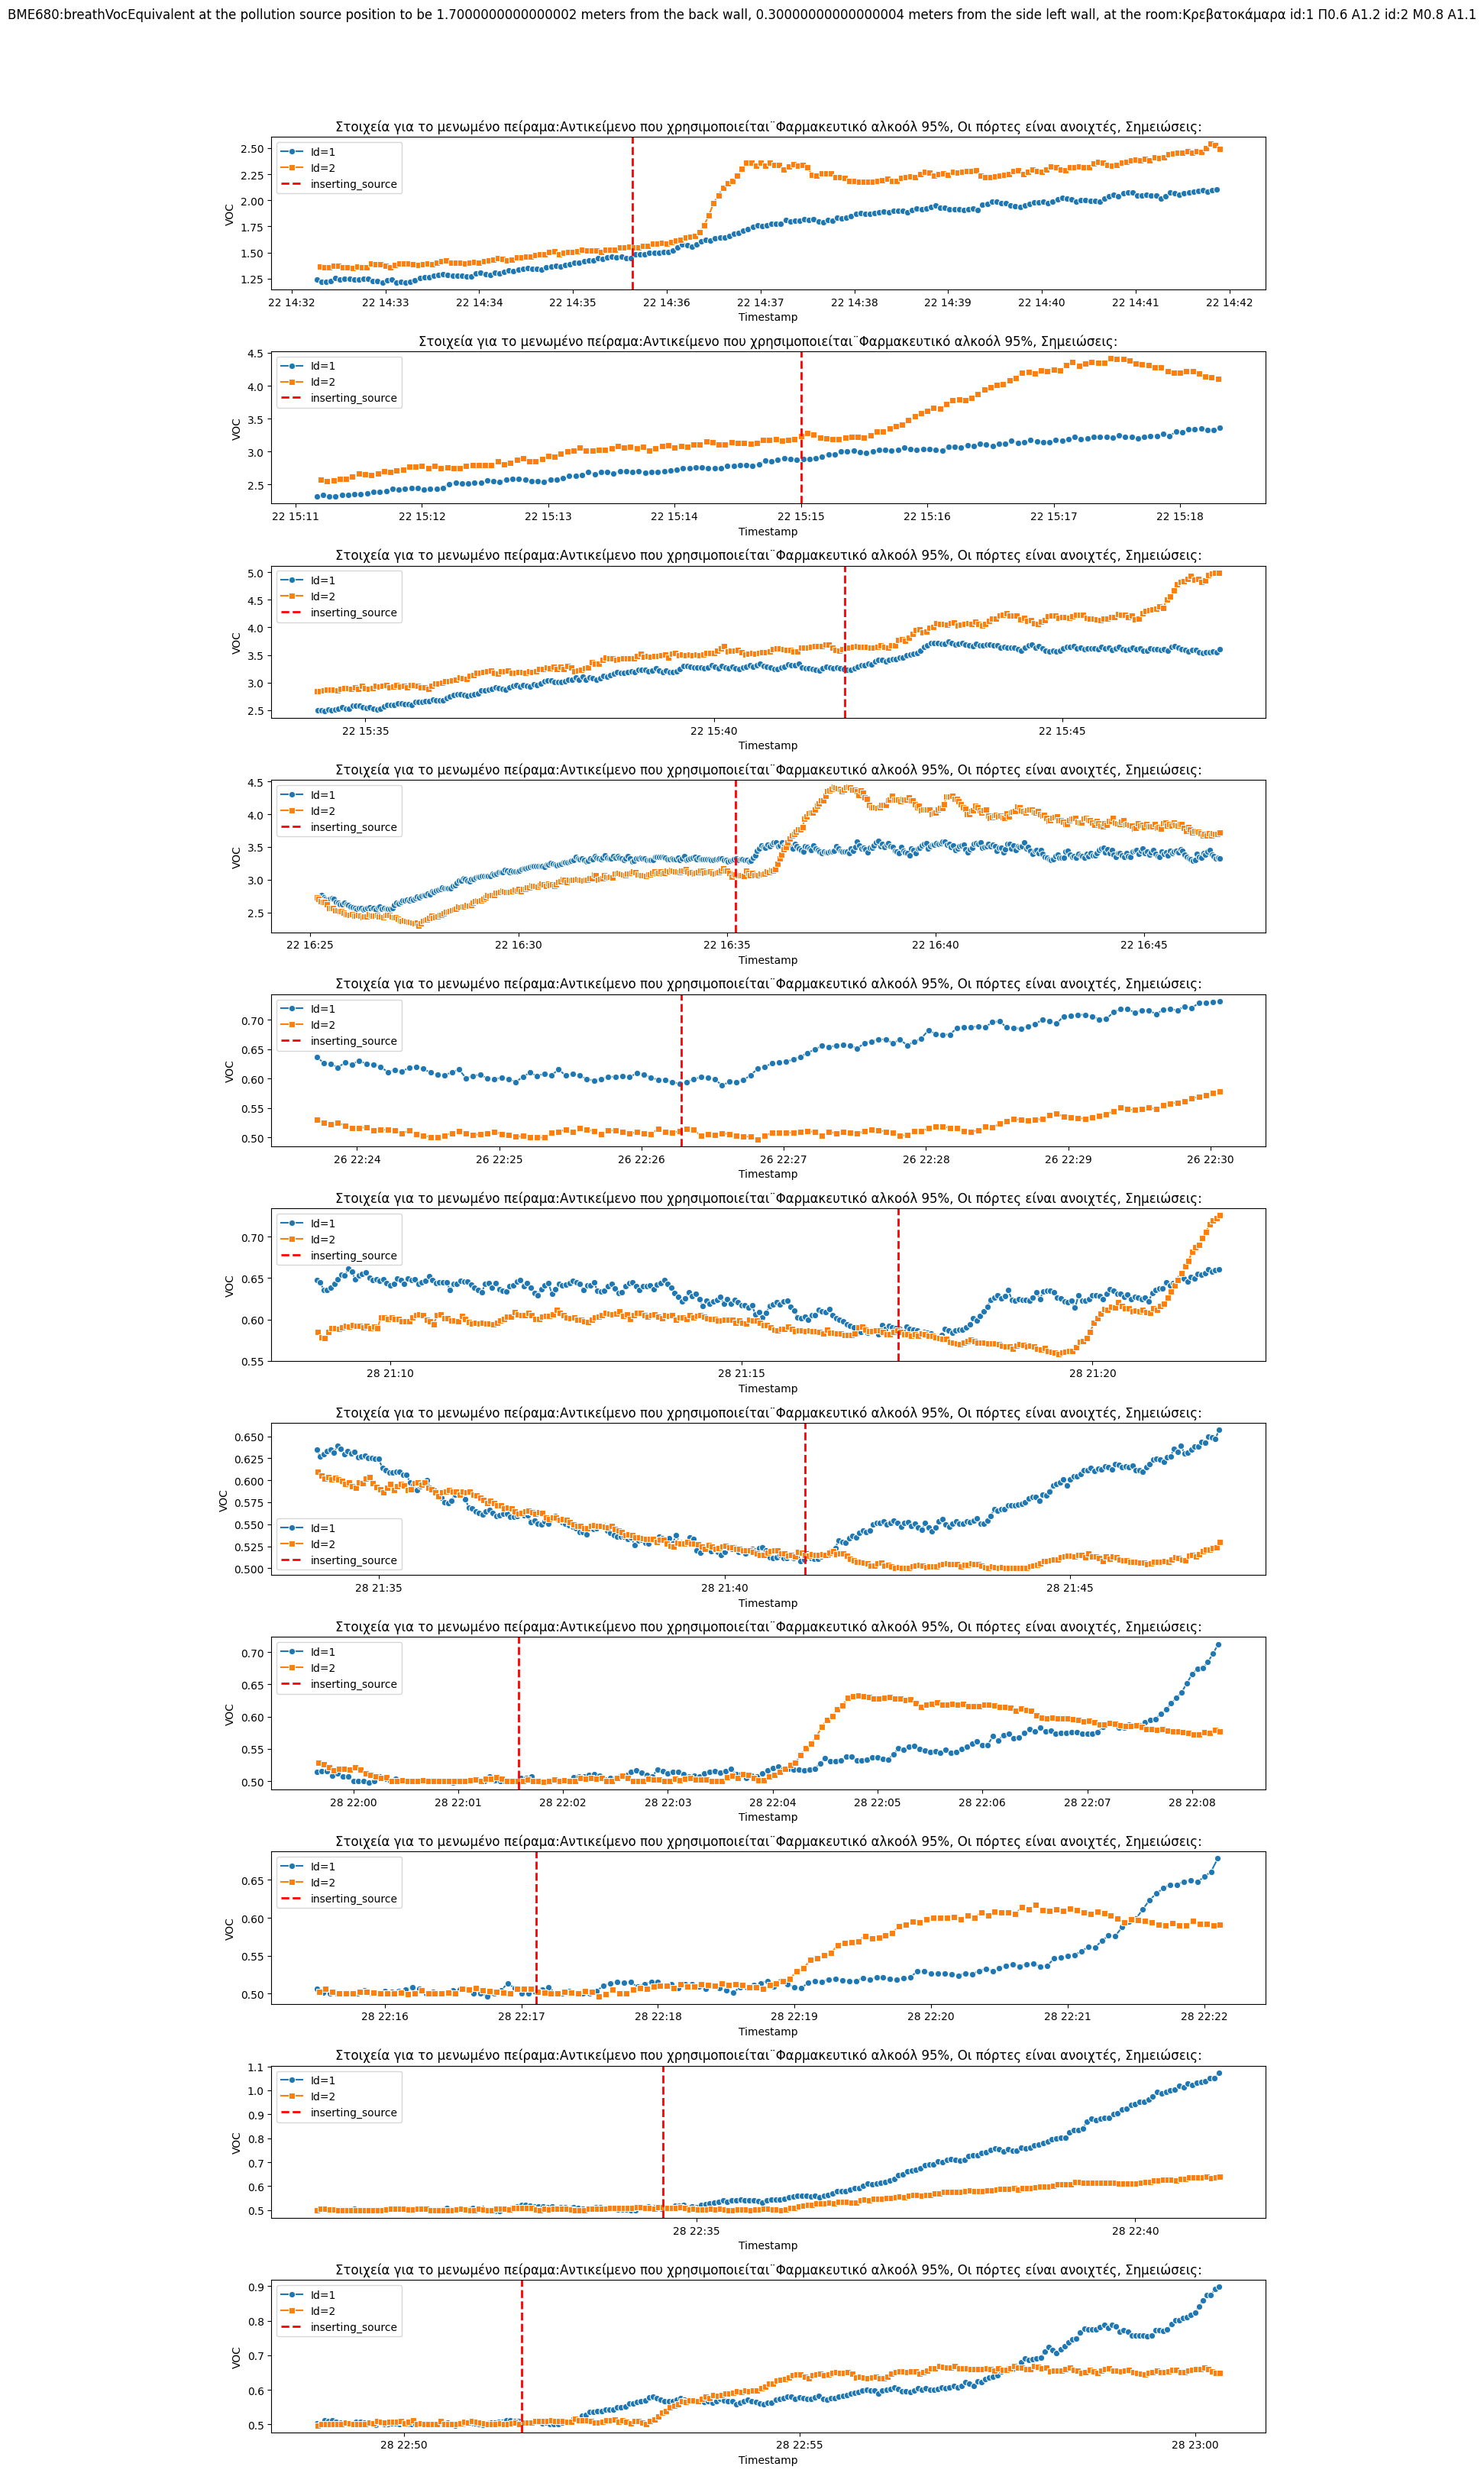

In [14]:
for i in range(0,((df_unique_position_count.shape[0]) - 1)):#we will set the starting source as two minutes before the inserting source and 3 minutes source after the inserting source
#check first if all the experiments at start experiment is at least two minutes before inserting source
    good_to_merge_start = True
    good_to_merge_end = True
    for df_exp_based_on_position in list_of_userInputData_smallScale_based_on_position:
        for index, row in df_exp_based_on_position.iterrows(): 
                index_df_small_scale = df_userInputData_smallScale.loc[df_userInputData_smallScale['_id'] == row['_id']].index[0]
                starting_experiment = df_userInputData_smallScale.iloc[index - 1] if index > 0 else None
                removing_source = df_userInputData_smallScale.iloc[index + 1] if index < len(df_userInputData_smallScale) - 1 else None
                if starting_experiment["timestamp_local"] > (df_userInputData_smallScale.iloc[index]["timestamp_local"] - timedelta(minutes=2)):
                    good_to_merge_start = False
                if removing_source["timestamp_local"] > (df_userInputData_smallScale.iloc[index]["timestamp_local"]  + timedelta(minutes=3)):
                    good_to_merge_start = False    
print("Starting experiment is more than two minutes:")
print(good_to_merge_start)
print("Ending experiment is more than two minutes:")
print(good_to_merge_end)
print_time_series_based_of_position(i,df_userInputData_smallScale,df_timeSeriesExperiments,list_of_userInputData_smallScale_based_on_position)

In [15]:
list_of_userInputData_smallScale_based_on_position_merged = []

for df_exp_based_on_position in list_of_userInputData_smallScale_based_on_position:
    # Make an explicit copy to avoid SettingWithCopyWarning
    df_exp_based_on_position = df_exp_based_on_position.copy()

    # Create new columns based on 'timestamp_local'
    df_exp_based_on_position["timestamp:Starting Experiment"] = df_exp_based_on_position["timestamp_local"] - timedelta(minutes=2)
    df_exp_based_on_position["timestamp:Ending Experiment"] = df_exp_based_on_position["timestamp_local"] + timedelta(minutes=3)

    # Rename original column
    df_exp_based_on_position.rename(columns={'timestamp_local': 'timestamp:Inserting Source'}, inplace=True)

    list_of_userInputData_smallScale_based_on_position_merged.append(df_exp_based_on_position)


In [16]:
list_of_userInputData_smallScale_based_on_position_merged[0]


,_id,experimentState,timestamp,userInputCategory,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,...,quantity-used,room,side-right-wall,back-wall,side-left-wall,are-fans-on,epoch_ms,timestamp:Inserting Source,timestamp:Starting Experiment,timestamp:Ending Experiment
1,{'$oid': '687bb3e92f9e1ee587c337ad'},InsertingSourcePollutant,{'$date': 1752937449439},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752937449439,2025-07-19 15:04:09.439,2025-07-19 15:02:09.439,2025-07-19 15:07:09.439
4,{'$oid': '687bb6f62f9e1ee587c33e98'},InsertingSourcePollutant,{'$date': 1752938230079},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752938230079,2025-07-19 15:17:10.079,2025-07-19 15:15:10.079,2025-07-19 15:20:10.079
7,{'$oid': '687bba292f9e1ee587c34606'},InsertingSourcePollutant,{'$date': 1752939049527},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752939049527,2025-07-19 15:30:49.527,2025-07-19 15:28:49.527,2025-07-19 15:33:49.527
10,{'$oid': '687bc4062f9e1ee587c35acd'},InsertingSourcePollutant,{'$date': 1752941574048},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752941574048,2025-07-19 16:12:54.048,2025-07-19 16:10:54.048,2025-07-19 16:15:54.048
13,{'$oid': '687bcbf52f9e1ee587c36c6b'},InsertingSourcePollutant,{'$date': 1752943605578},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752943605578,2025-07-19 16:46:45.578,2025-07-19 16:44:45.578,2025-07-19 16:49:45.578
16,{'$oid': '687bd5102f9e1ee587c3800b'},InsertingSourcePollutant,{'$date': 1752945936836},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752945936836,2025-07-19 17:25:36.836,2025-07-19 17:23:36.836,2025-07-19 17:28:36.836
19,{'$oid': '687cf31b9ca8d3ed9388a101'},InsertingSourcePollutant,{'$date': 1753019163466},ExperimentState,on,None,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1753019163466,2025-07-20 13:46:03.466,2025-07-20 13:44:03.466,2025-07-20 13:49:03.466
22,{'$oid': '687d08169ca8d3ed9388c9c1'},InsertingSourcePollutant,{'$date': 1753024534869},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1753024534869,2025-07-20 15:15:34.869,2025-07-20 15:13:34.869,2025-07-20 15:18:34.869
25,{'$oid': '687d1a9f29a17fa9a903c98f'},InsertingSourcePollutant,{'$date': 1753029279532},ExperimentState,on,None,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1753029279532,2025-07-20 16:34:39.532,2025-07-20 16:32:39.532,2025-07-20 16:37:39.532
28,{'$oid': '687d31b3ef9fa667a2542024'},InsertingSourcePollutant,{'$date': 1753035187541},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,...,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1753035187541,2025-07-20 18:13:07.541,2025-07-20 18:11:07.541,2025-07-20 18:16:07.541


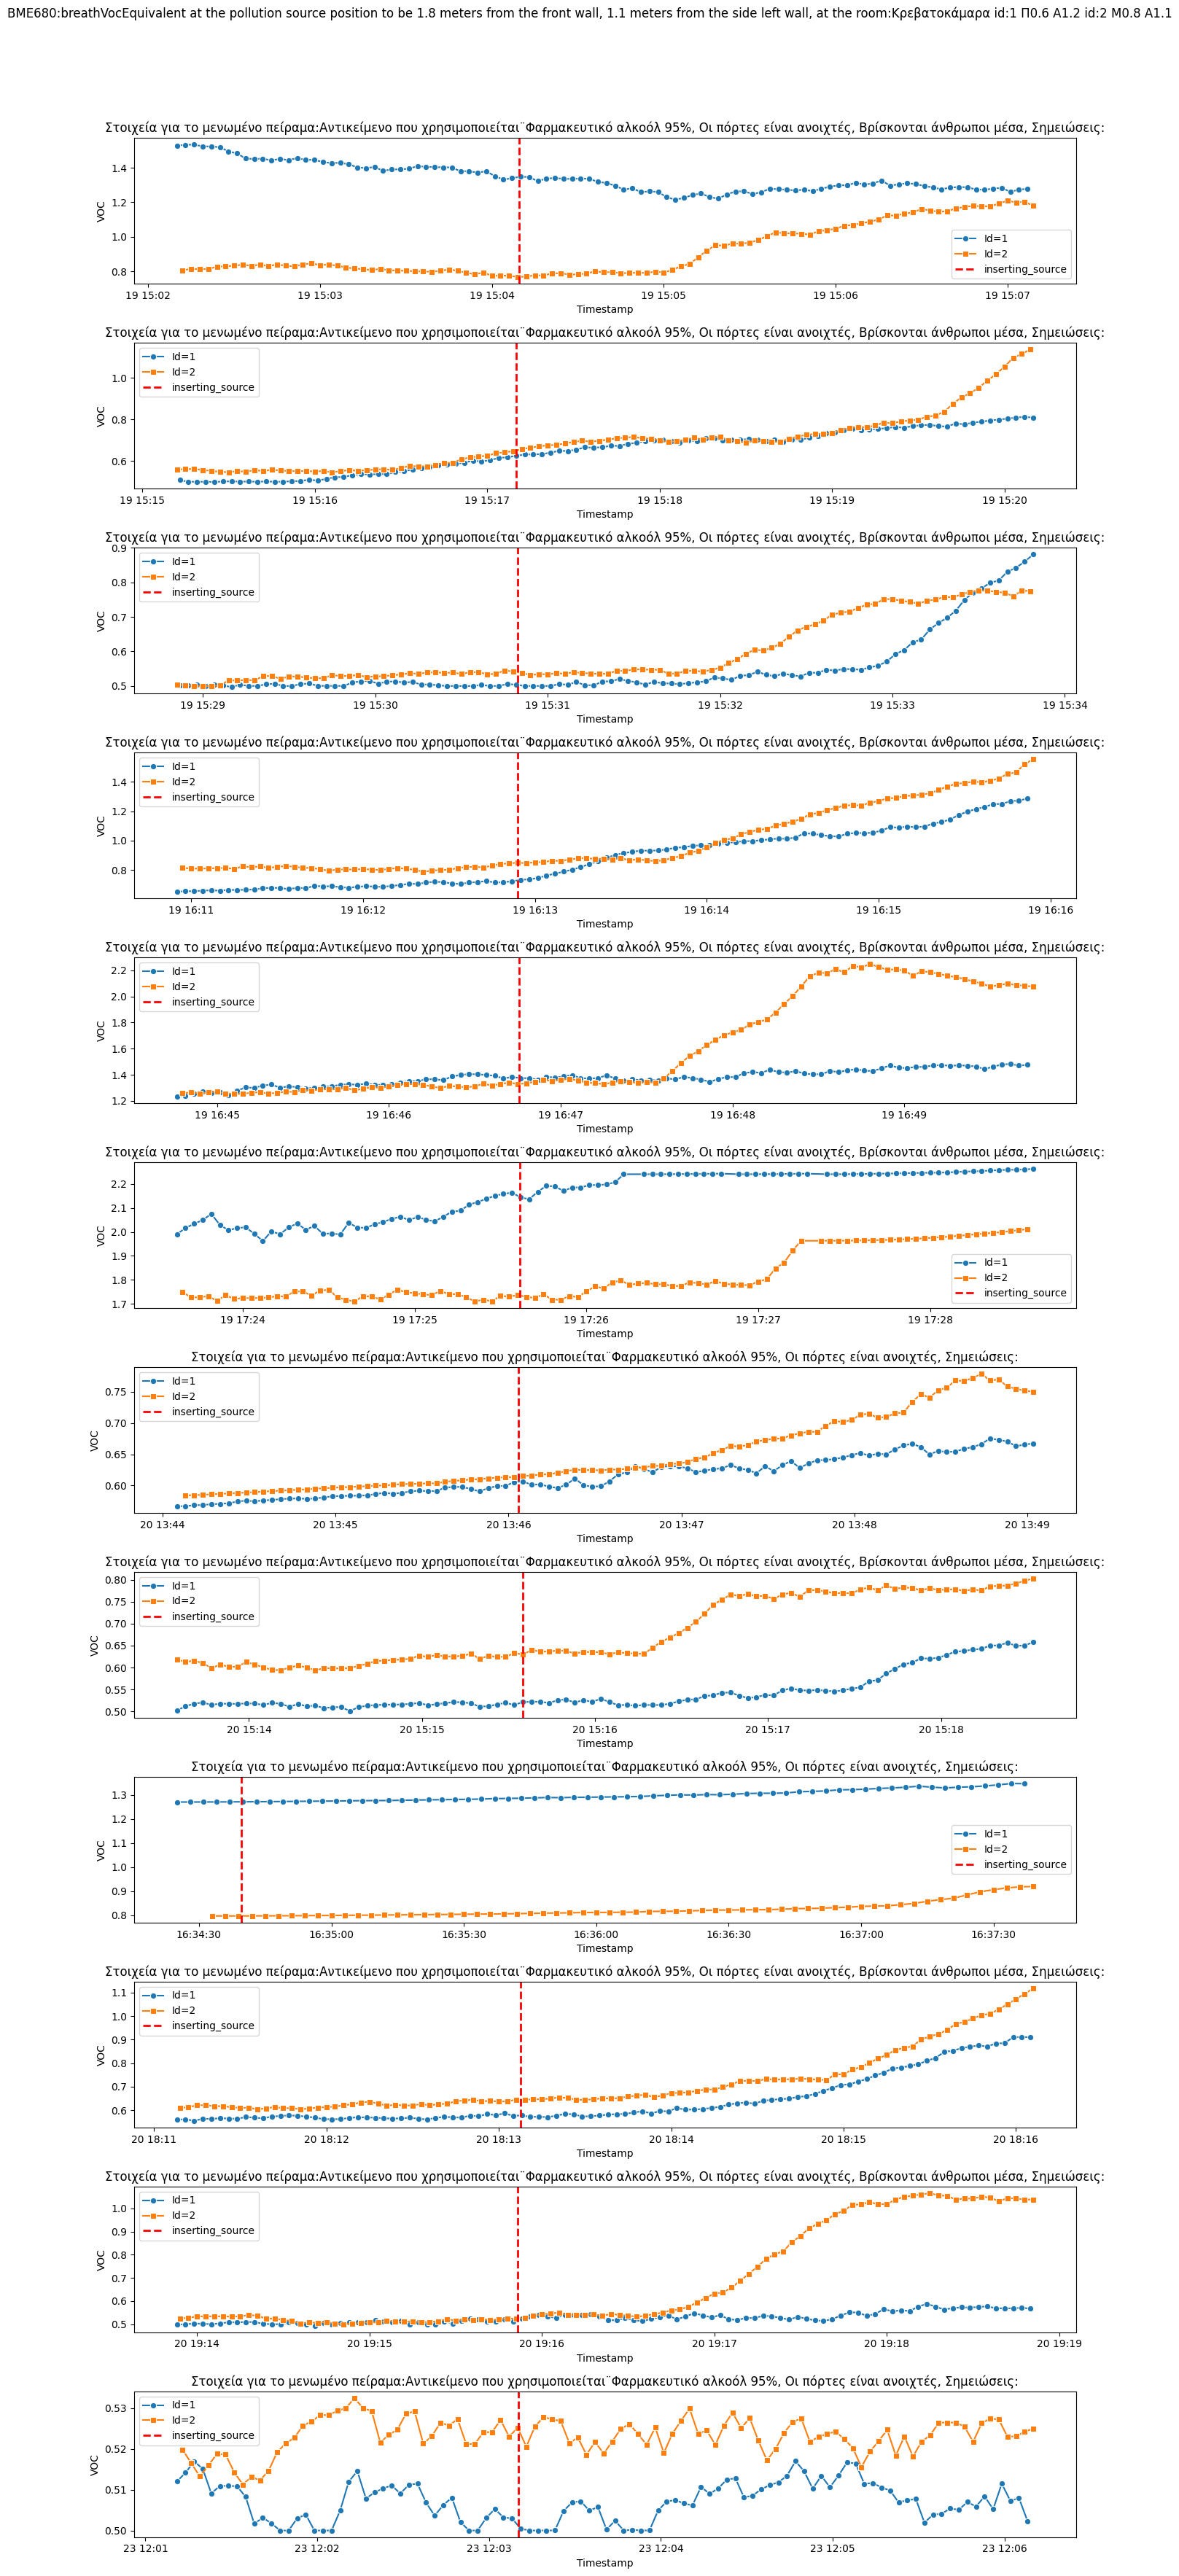

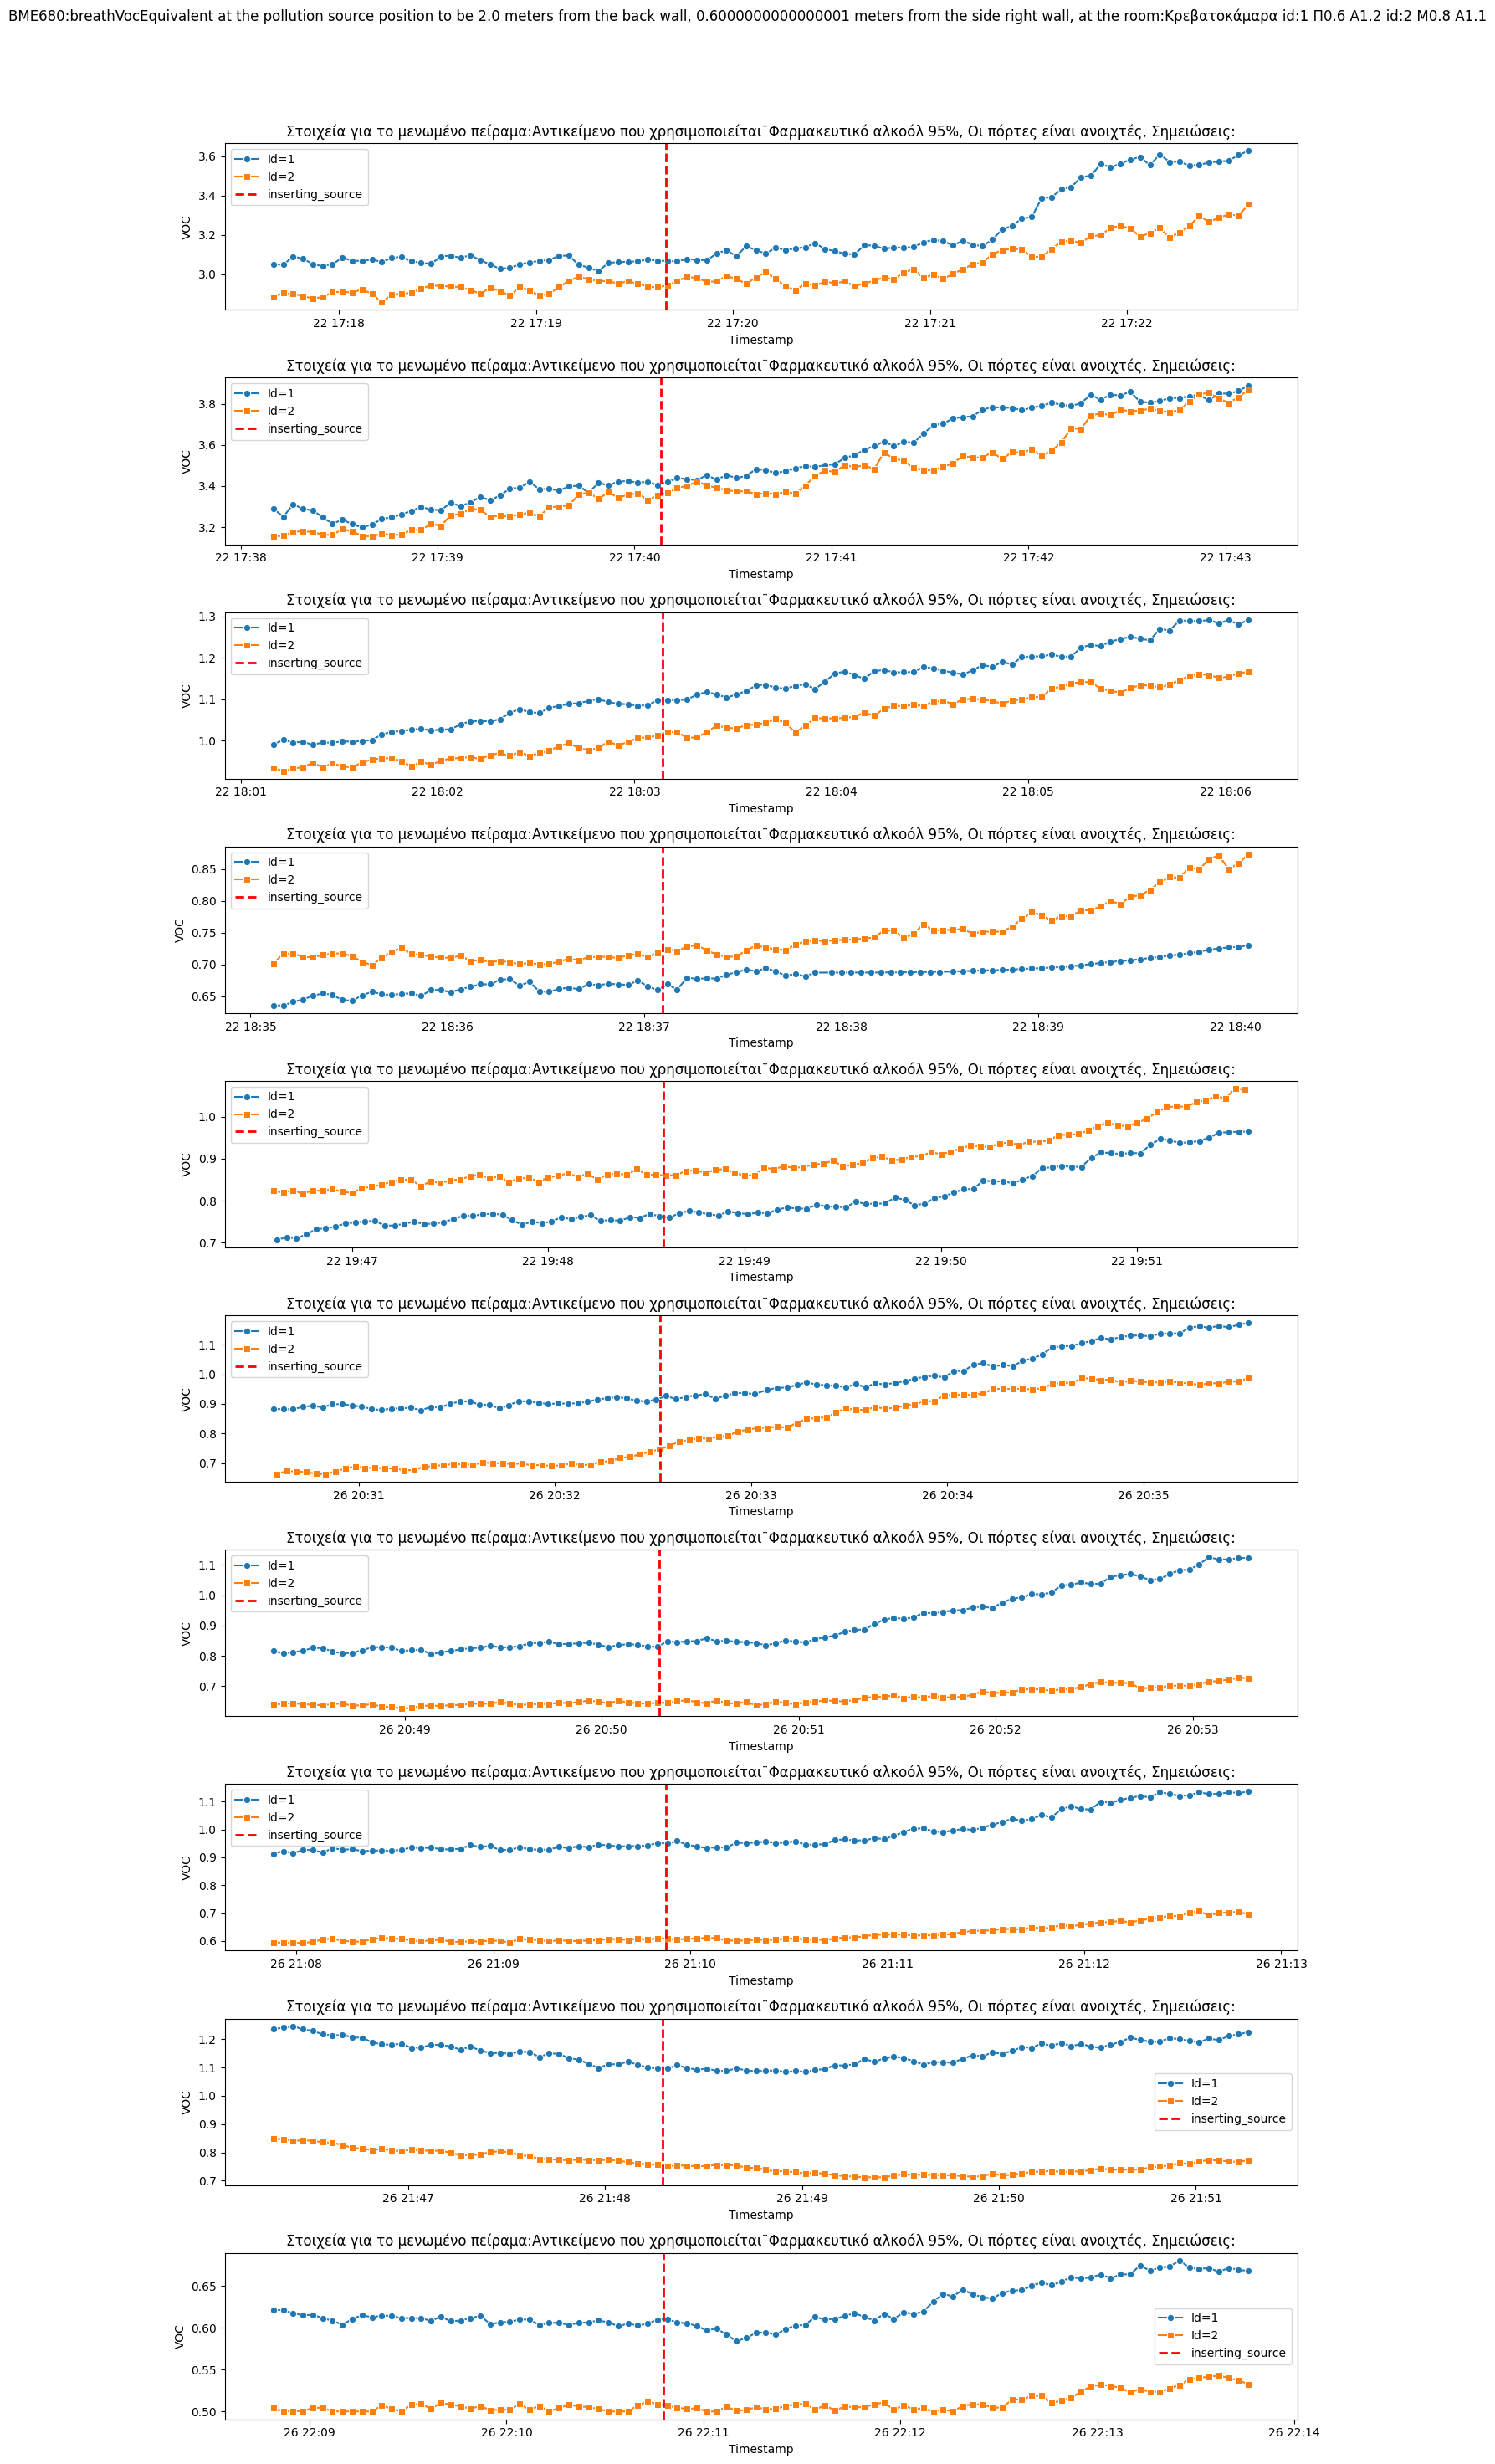

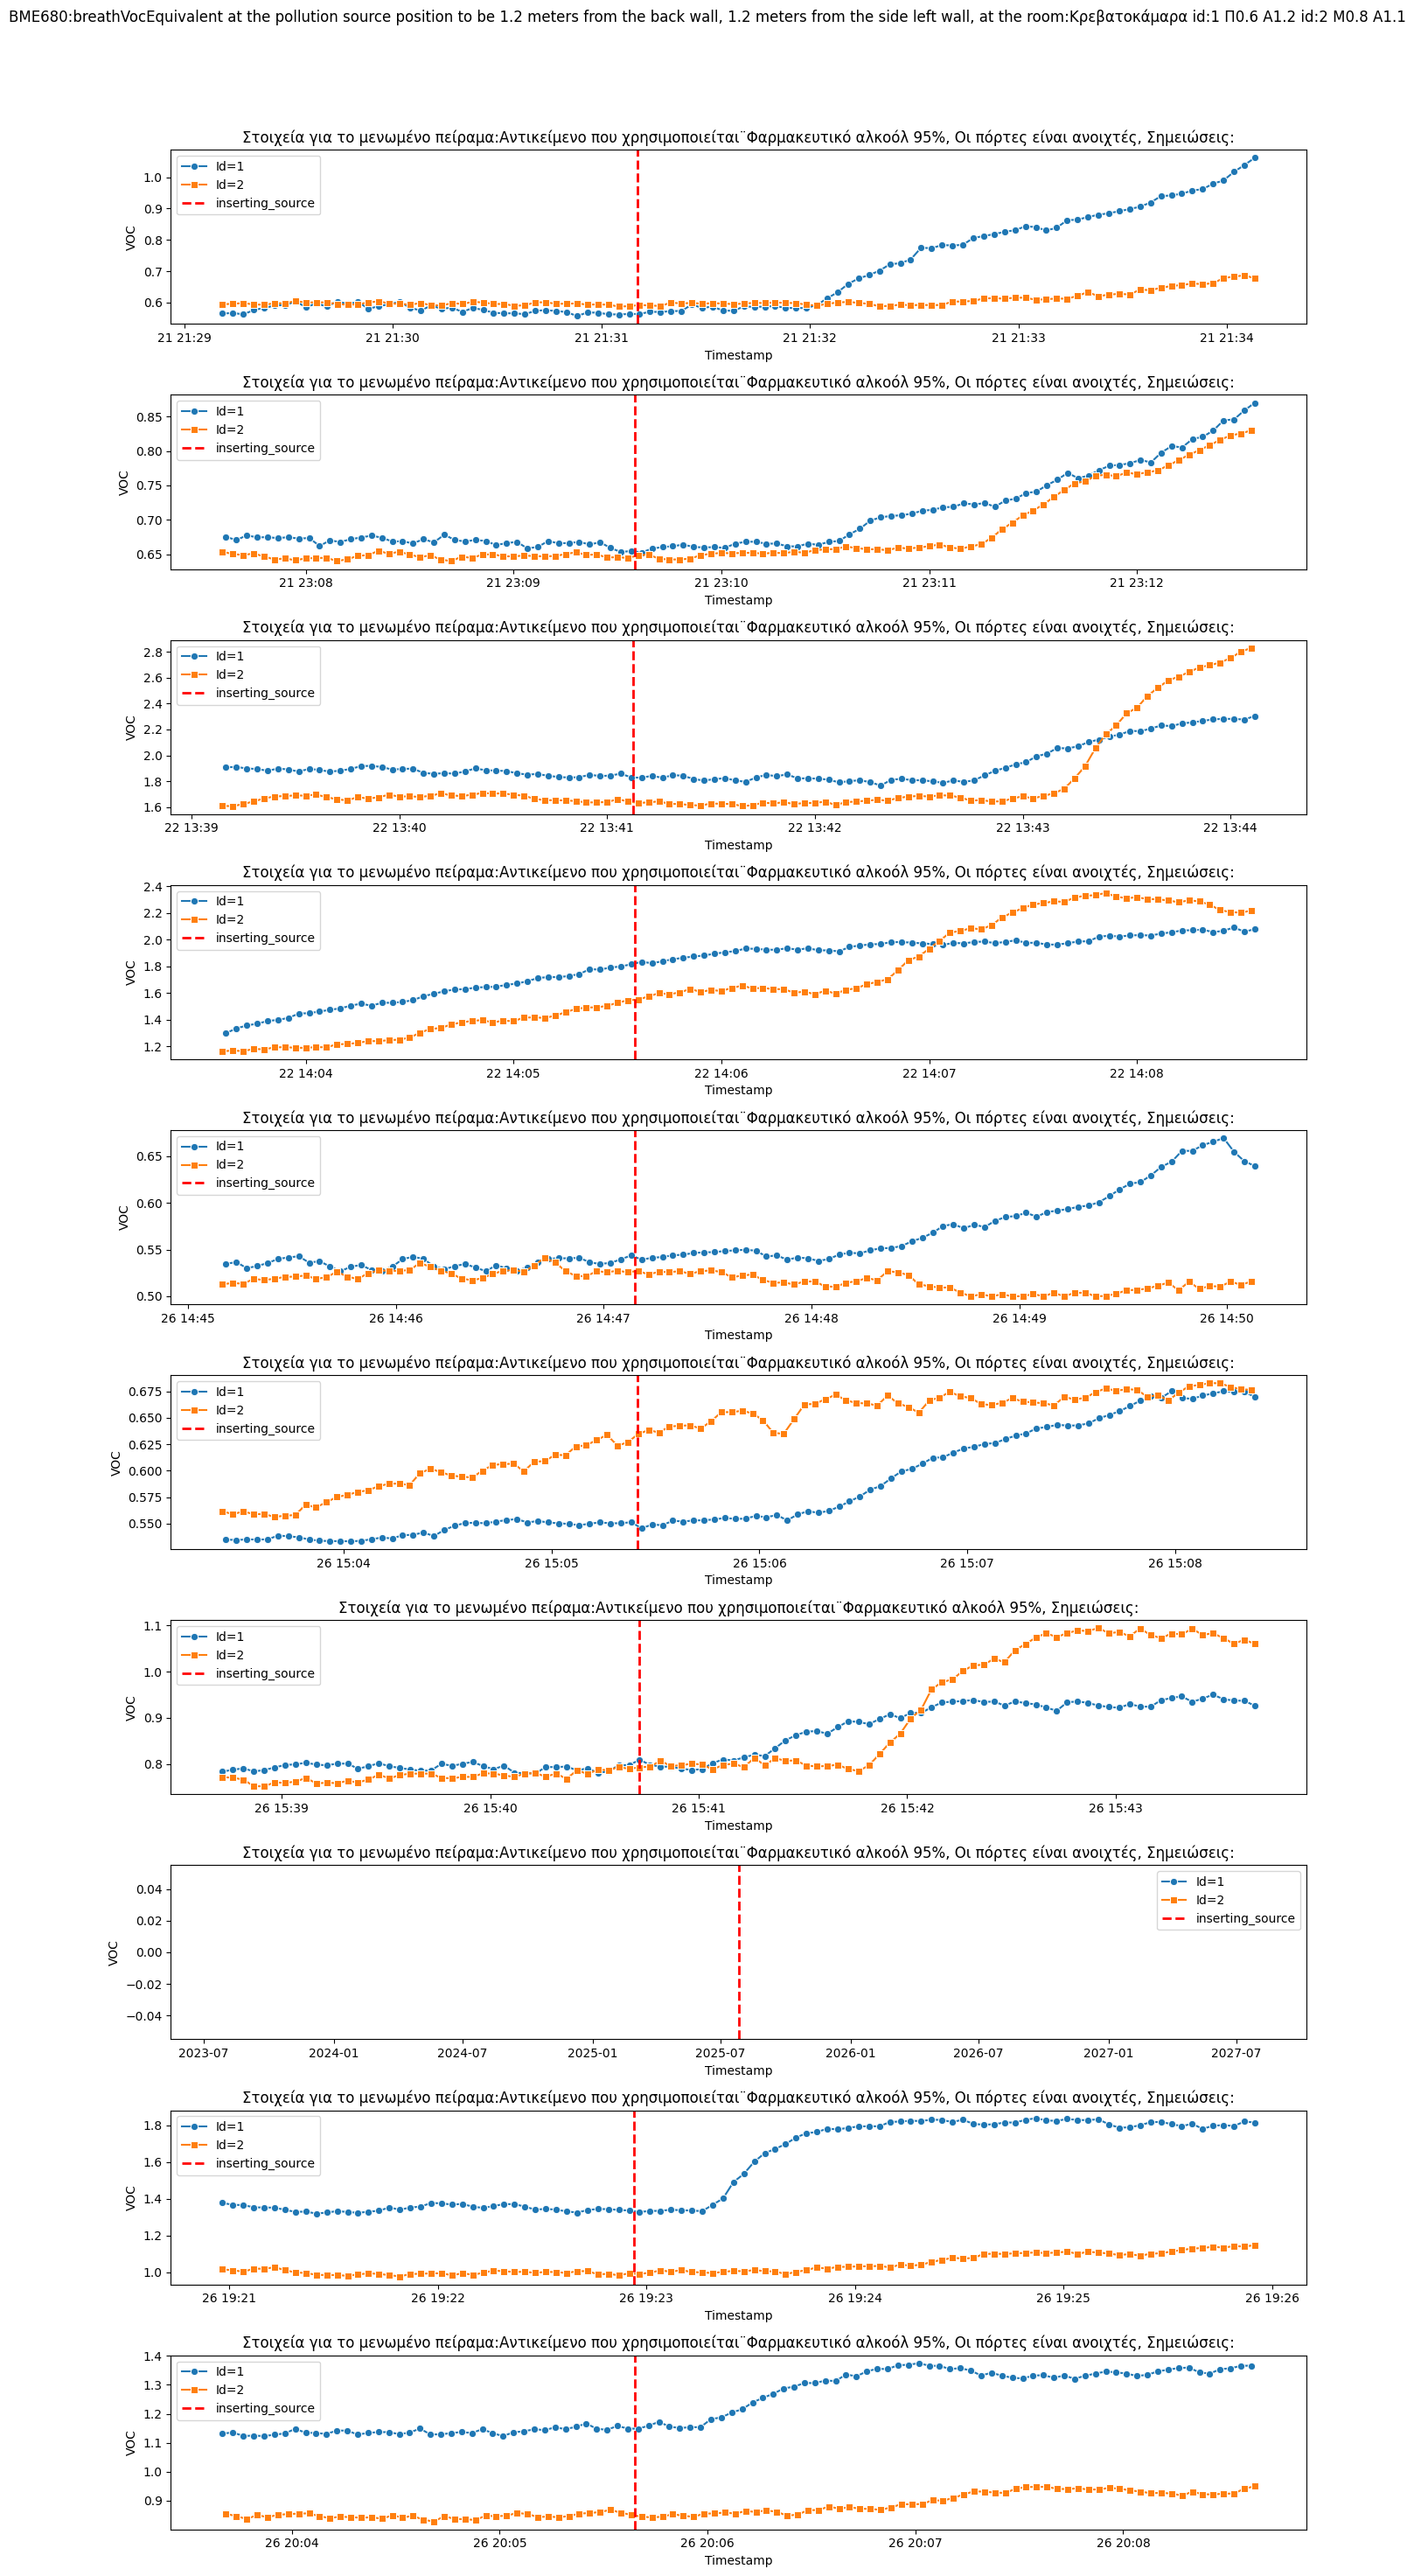

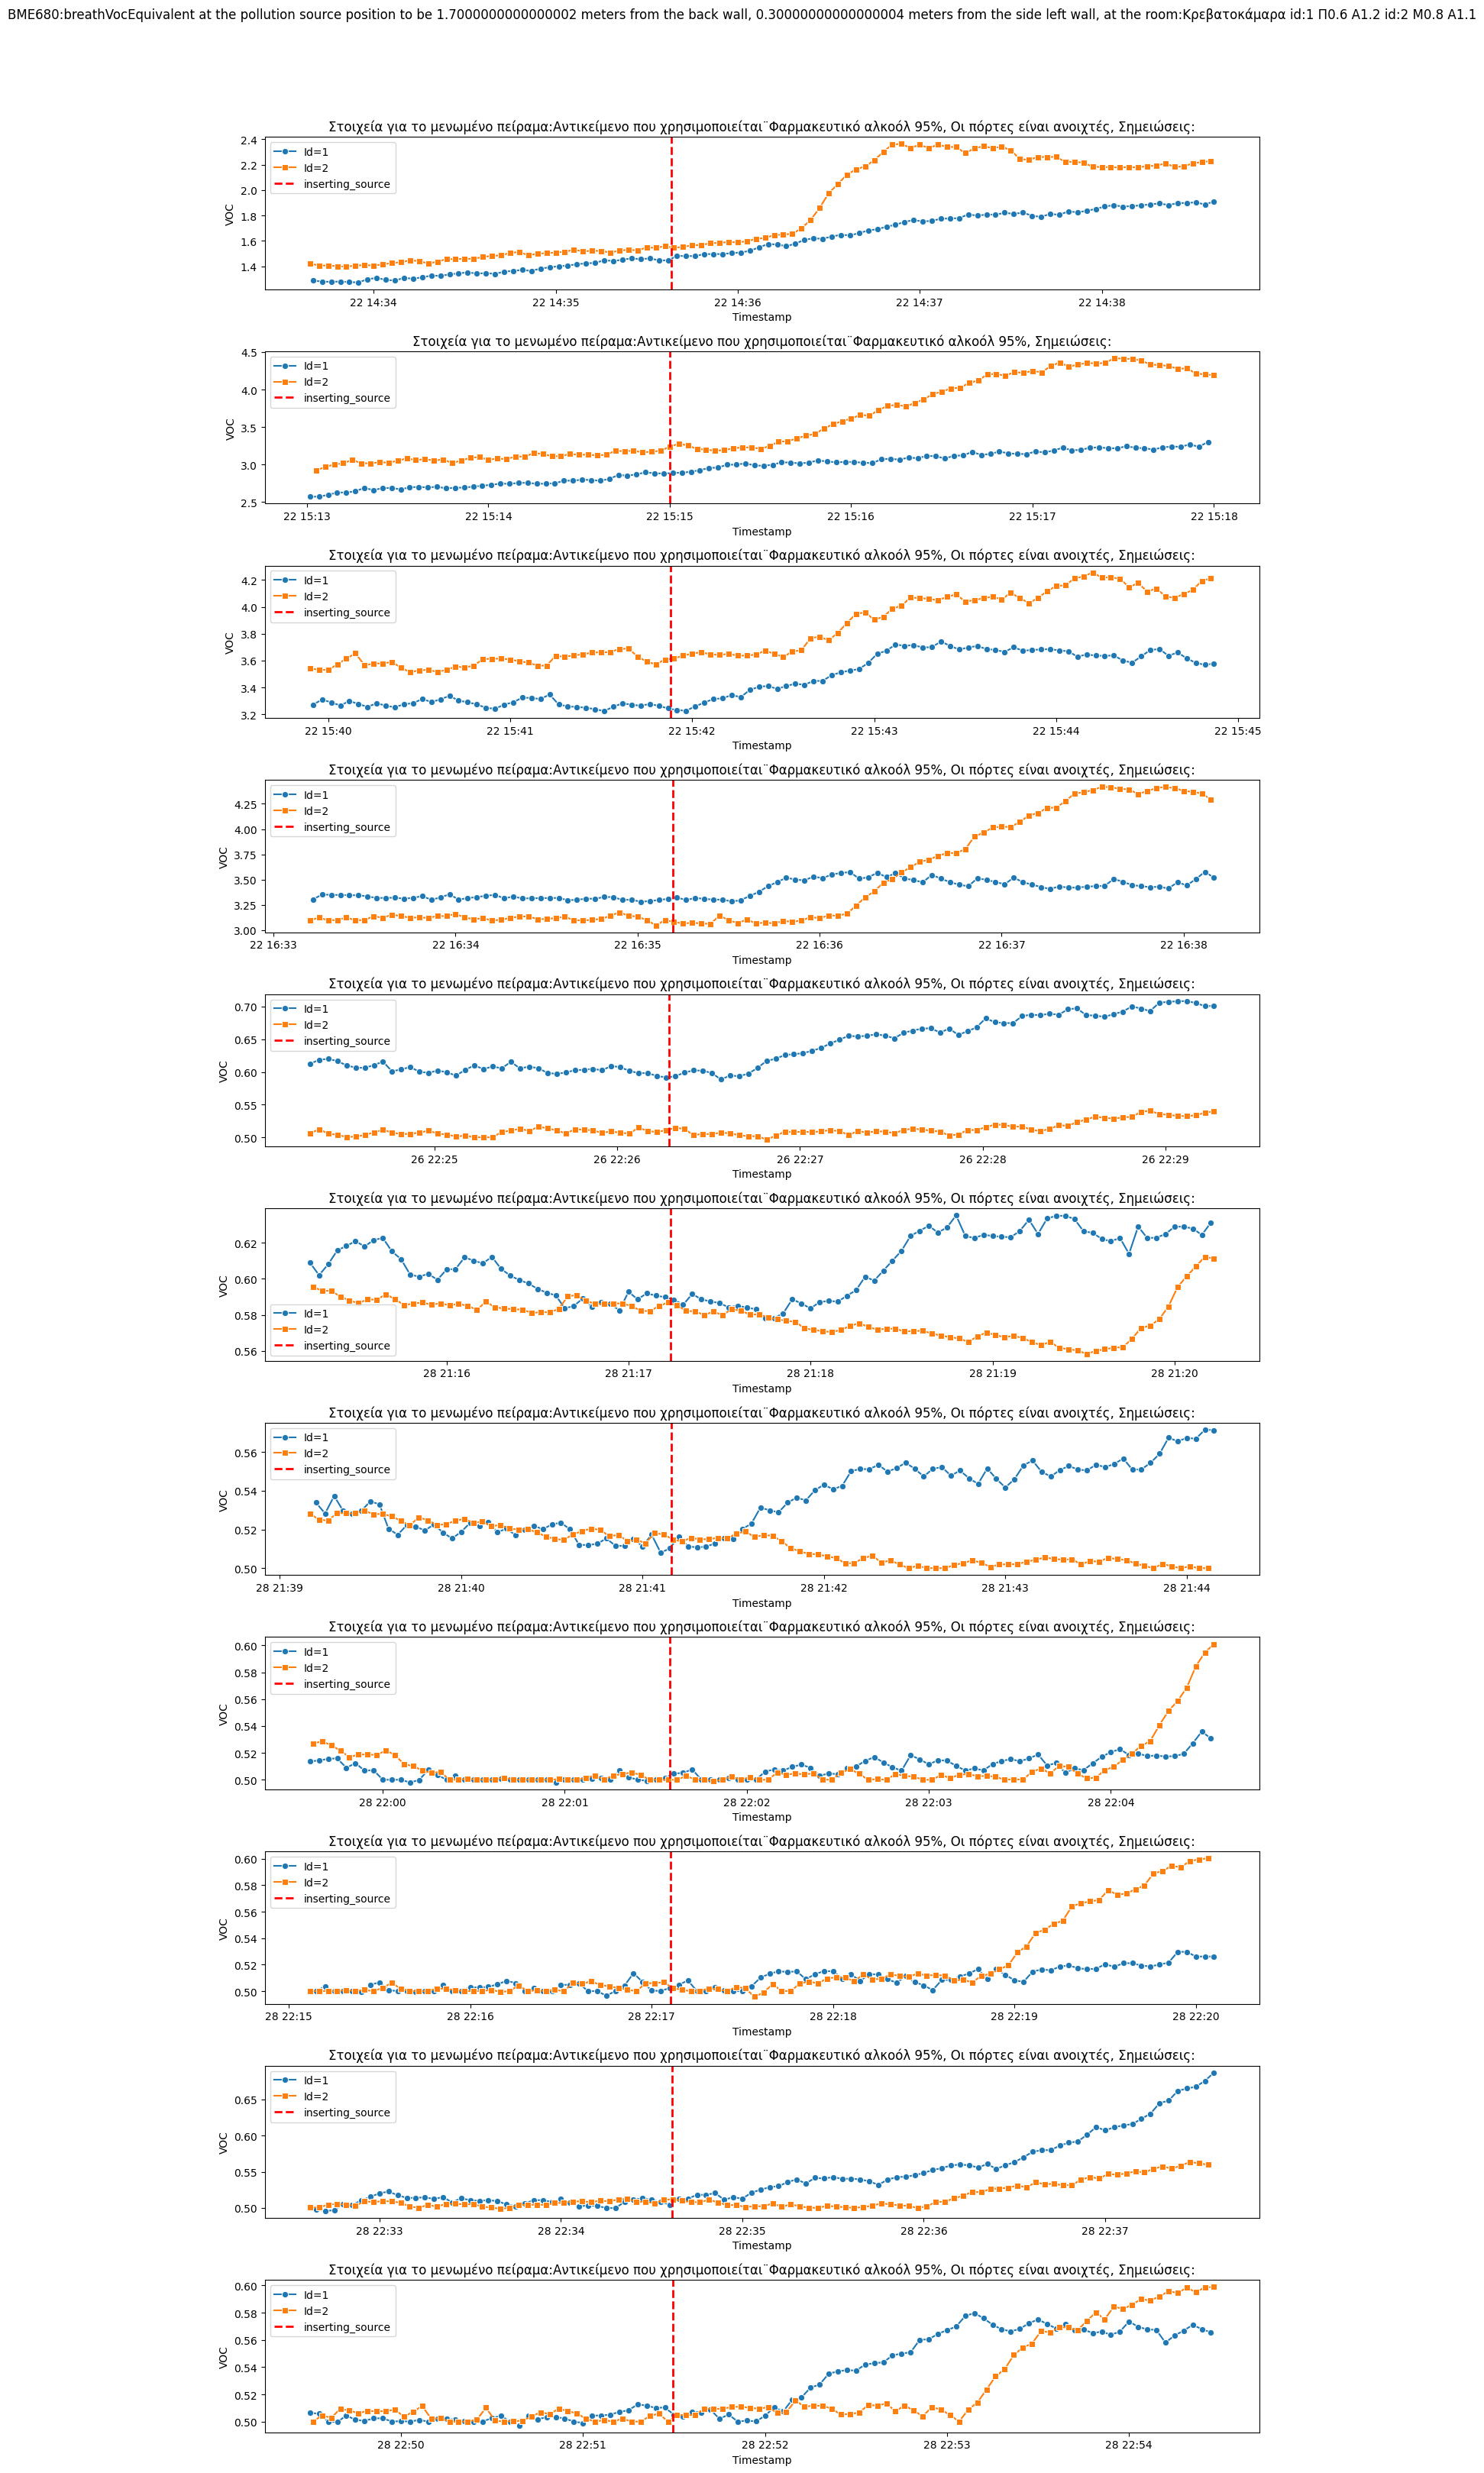

In [17]:
for i in range(0,((df_unique_position_count.shape[0]) - 1)):
        print_time_series_based_of_position(i,df_userInputData_smallScale,df_timeSeriesExperiments,list_of_userInputData_smallScale_based_on_position_merged)